# Using optimization techniques for model fit

## work smarter not harder

Let's use a smarter strategy.

Lucky for us, `scipy` includes some very powerful numerical optimization algorithms in the `scipy.optimize` module.

So much like before, we have to give a function $f(x)$ to minimize based on choosing values of $x$ -- here it is the best-fit `model_fn` from above with our fitted $(a, b, c, d, e)$ parameters. But now let's feed that into our optimize functions.

In [ ]:
import numpy as np
from scipy import optimize
from scipy.optimize import curve_fit

# Step 1: Let's retrive our dataset - first cell with our raw data
# approximation of data shown in the paper (given)
x = np.linspace(0, 120, 100) # start, stop, number of samples
y = (79/4200)*x**2-(1039*x/420)+101  + np.random.randn(len(x)) * 5

# Step 2: Function to approximate ("fit") our dataset
# define a model/function for fitting our data
def model_fn(x,a,b,c,d,e):
  y = a * (x-b)**2 + c*(x-d) + e
  return y

# determine the parameters usign curve_fit
params, variance = curve_fit(model_fn, x, y)

# Step 3: Define an objective - minimize y/f(x) for given x
# now that we know the parameters, we can have the function only depending on x
def objective_function(x):
  # calling the function above
  y = model_fn(x, params[0], params[1], params[2], params[3], params[4])
  return y  # output is y

# Step 4: Let's test our function with initial guess

#decent guess
x0 = 62
y0 = objective_function(x0)
print("y for x0: ", y0)

#bad guess
x1 = 200
y1 = objective_function(x1)
print("y for x1: ", y1)

# Step 5: Minimizing our function using the scipy method optimize.minimize()
result = optimize.minimize(objective_function, x0)
print("result from optimization: ")
print(result)

There is a lot to **unpack here**, i.e. output from function minimize().

The output from `minimize` is stored in a data structure.
The most important parts are `fun`, which is **the optimal $f(x)$**, and $x$, **which is the value of $x$ to achieve that**.


In [ ]:
# just to compare with before

x_test2 = np.linspace(0, 120, int(1e7)) # look at a bigger space, use 10 million values!
y_test2 = model_fn(x_test2, params[0], params[1], params[2], params[3], params[4])

# finding min using arg min
min_index2 = np.argmin(y_test2)
y_min2 = y_test2[min_index2]
x_min2 = x_test2[min_index2]

print('minimum value is y ', y_min2)
print('minimum occurs at x ', x_min2)

Another interesting piece of information is the `nfev` entry, which is the *number of function evaluations*.

Here you can see that the **function was only evaluated a 10 times to locate the minimum value**, which is very similar to the min using 10 million entries!

And it doesn't require us to specify a range or anything like that.

This is much more efficient than our grid search.

and now if we wanted to plot this value on our original data from above, we could do

In [ ]:
from matplotlib import pyplot as plt

# plot the data
fig, ax = plt.subplots()
ax.scatter(x,y)
ax.set_xlabel('height of the building')
ax.set_ylabel('cost')

# plot the model
ax.plot(x, model_fn(x, params[0], params[1], params[2], params[3], params[4]), "orange")

# plotting the min based on optimization
x_min = result.x
y_min = result.fun
ax.plot(x_min, y_min , 'd', markersize = 24, color='red')

print('the lowest value is ', result.fun, ' and it occurs at ', result.x)

## examples where you would expect a quadratic behaviour/polynomial in AE:

<!-- * Lighting: maximizing illuminated area between two bulbs

* Structural: lowest point in cables on suspension bridge
https://tbaisdmtacgidner1.weebly.com/civil-engineering-applications-of-the-quadratic-function.html

* Mechanical: kinetic energy vs velocity of fluid

* Construction / lighting: life cycle costs vs energy efficiency of a glazing (might have diminishing returns there.we will see this below and that might fit a bit better). -->

### Lighting: Useful Daylight Illuminance (UDI) vs. Daylight Factor
In contemporary lighting design, the goal is not simply to maximize the amount of daylight in a room, but to maximize the amount of useful daylight. The concept of Useful Daylight Illuminance (UDI) captures this by measuring the percentage of time that the light levels in a space are within a beneficial range, not too dark and not too bright. The provided graph plots this UDI against the traditional Daylight Factor, showing a clear optimization curve.

**Too little daylight (Low Daylight Factor):** When the Daylight Factor is very low, the space is consistently under-lit. Light levels are often below the useful threshold (e.g., 100 lux), meaning the daylight offers little help for visual tasks and artificial lighting is almost always required.

**Too much daylight (High Daylight Factor):** As the Daylight Factor increases, more light enters the space. However, beyond a certain point, the light levels become excessive. They frequently surpass the upper threshold (e.g., 2000 lux), which can lead to significant visual discomfort from glare and thermal discomfort from solar heat gain. As a result, the percentage of time the daylight is "useful" begins to decrease.

The peak of the parabola represents the Optimal Daylight Factor, here it is between 2% and 4%. At this point, the design achieves the highest possible UDI, with values ranging from 88% to over 99% depending on the window's orientation. For an architect or engineer, hitting this target means creating a space that maximizes comfortable, energy-saving natural light while minimizing the negative effects of glare and overheating.

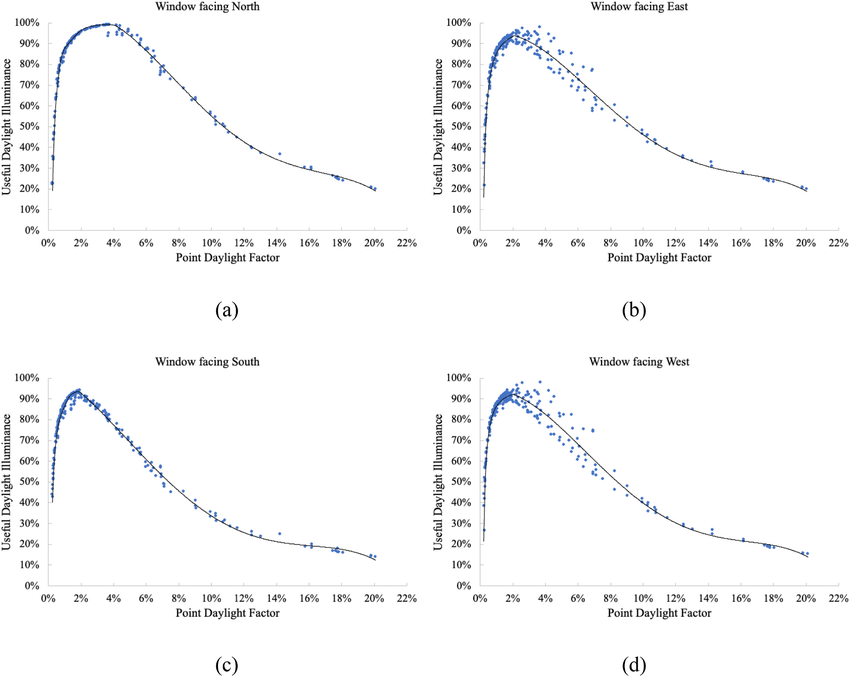

https://www.researchgate.net/publication/370308394_Simple_mathematical_models_to_link_climate-based_daylight_metrics_with_daylight_factor_metrics_and_daylighting_design_implications/link/6461b01cfbaf5b27a4c97513/download?_tp=eyJjb250ZXh0Ijp7ImZpcnN0UGFnZSI6Il9kaXJlY3QiLCJwYWdlIjoicHVibGljYXRpb24iLCJwcmV2aW91c1BhZ2UiOiJfZGlyZWN0In19

### Structural: Optimal Structural Core Size vs. Leasable Area
In the design of mid-rise and high-rise buildings, a critical optimization problem is determining the size of the central structural core. This core typically contains elevators, stairwells, and mechanical shafts, while also providing the primary resistance to wind and seismic forces. The relationship between the size of this core and the net leasable floor area (the space that generates revenue) can be modeled as a parabola.

**Too small a core:** The building becomes structurally inefficient. To compensate, perimeter columns must be made much larger, or additional bracing must be added, both of which consume valuable floor space and obstruct views. Functionally, a small core cannot house enough elevators, leading to unacceptable wait times for occupants.

**Too large a core:** The structure is very stable, but it directly subtracts from the available floor space that can be leased to tenants. This is a direct loss of potential revenue for the building owner.

The peak of the parabola represents the optimal core size. This is the sweet spot where the building has maximum structural and functional efficiency without sacrificing excessive amounts of profitable, leasable area. Engineers and architects work to find this peak to maximize the economic viability of a project.

### Construction: Soil Compaction Curve (Proctor Curve)
In construction, ensuring the ground is stable enough to support a building, road, or foundation is important.
This is achieved by compacting the soil.
The relationship between the moisture content of the soil and the density you can achieve through compaction forms a distinct parabolic curve. This is known as a Proctor curve.

**Too dry:** When soil has too little water, the friction between the particles is high, preventing them from packing together tightly. The resulting density is low.

**Too wet:** When soil has too much water, the water fills the spaces between the particles and pushes them apart, preventing tight packing. Again, the density is low.

The peak of the parabola represents the Optimal Moisture Content (OMC). At this exact water level, the soil can be compacted to its Maximum Dry Density (MDD). Geotechnical engineers and construction managers perform a Proctor test to find this peak. On site, they can then add the precise amount of water needed to achieve the strongest and most stable ground conditions possible.

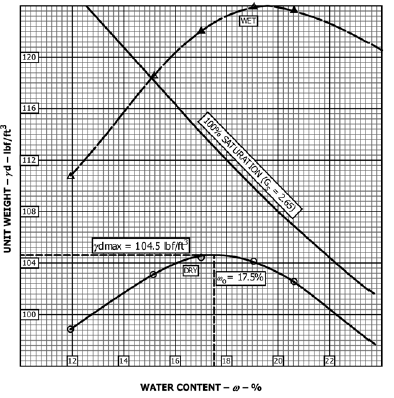

https://www.globalgilson.com/blog/proctor-compaction-test-a-basic-guide?srsltid=AfmBOorqf0HkZmPvWRenk6QRzfxY1M5RcLaZO1lqeo6-ifh6_9E2ERye

### Mechanical: Pump Performance Curve
In designing HVAC and plumbing systems, engineers select pumps to move water for heating, cooling, or domestic use. Every pump has a performance curve that shows the relationship between the flow rate it produces and the pressure (or "head") it can generate.

This curve is almost always a downward-opening parabola. At the same time, the pump's efficiency also forms a parabolic curve relative to the flow rate. The engineer's critical task is to select a pump where its Best Efficiency Point (BEP), the peak of the efficiency parabola, aligns with the required flow and pressure of the building's piping system. Operating a pump at its BEP minimizes energy consumption over the life of the building.

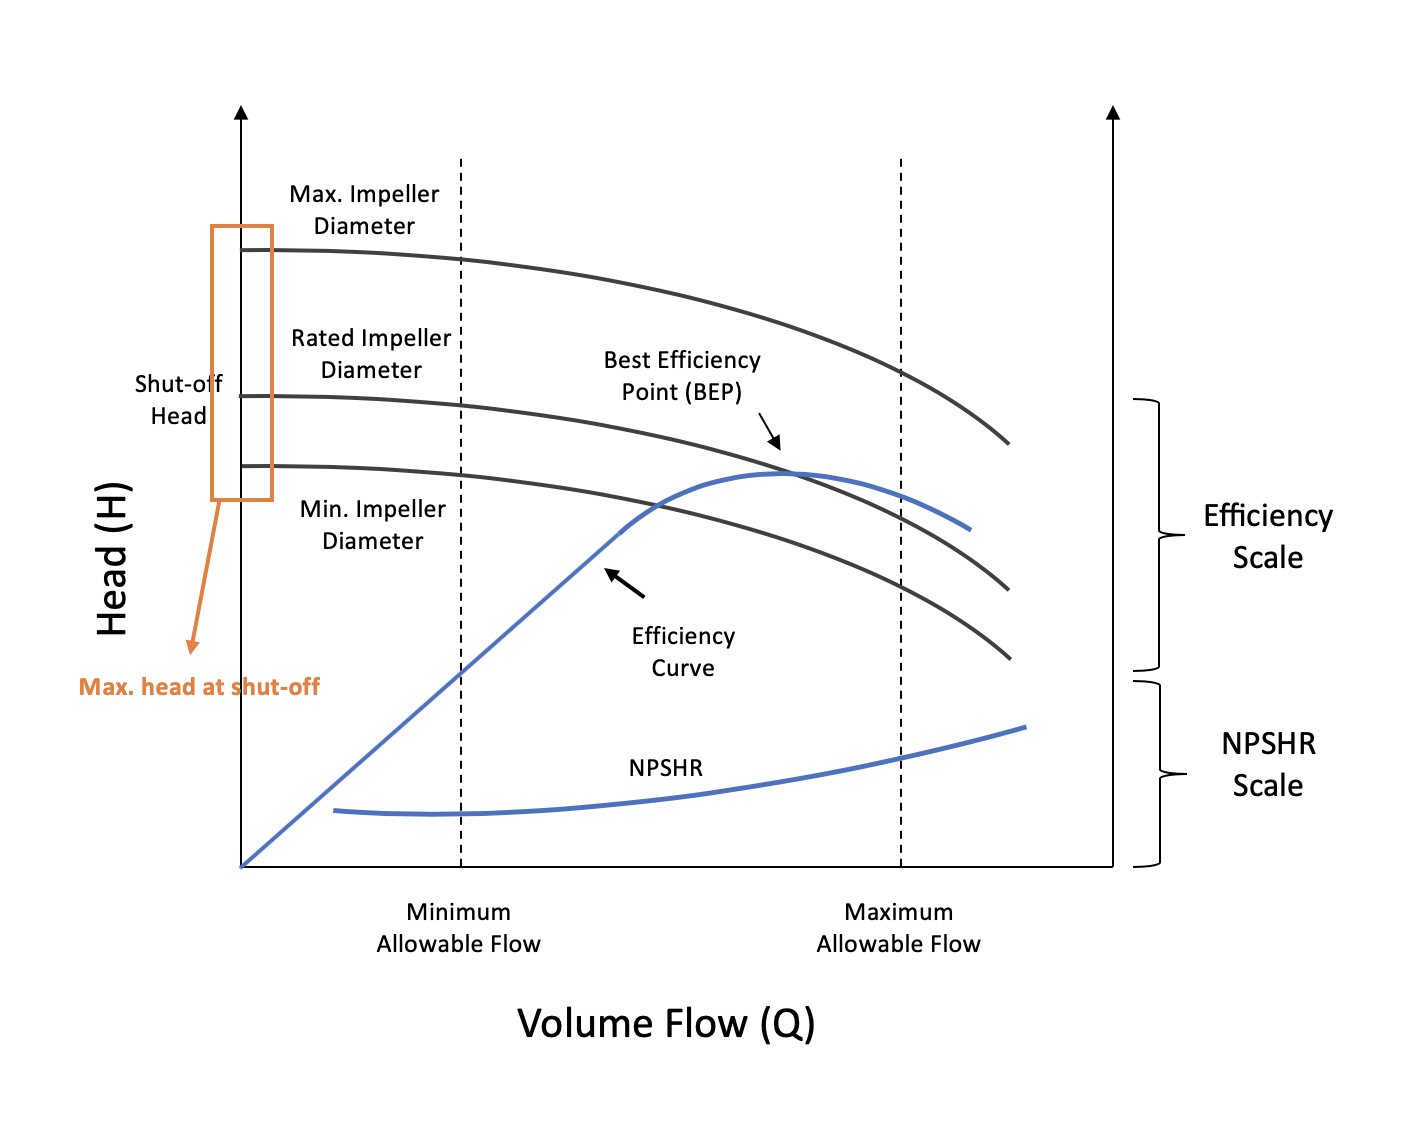

https://upload.wikimedia.org/wikipedia/commons/0/06/Pump_Characteristic_Curve.png

For the curious, information about why we do local search (make a guess) with scipy instead of just looking at it globally: https://machinelearningmastery.com/function-optimization-with-scipy/


### **Your turn Class #2** ⏰ (10mins)

Find the **optimum** result (x & y values corresponding to optimum) for the following data - please see the instructions along the way.

In [ ]:
import numpy as np

x_new = np.linspace(-1, 1, 100)
y_new = -(x_new - 0.2)**2 + np.random.randn(len(x_new)) * 0.04

### Step 1 - let's plot our dataset to see how it looks like

In [ ]:
# your code here

### Step 2 - let's use a model to fit our data!

Essentially, we will do what we've been learning since last week:

1) Define a nonlinear function/model for our data.

2) Use curve_fit() to find the function's parameter.

3) Plot the function as a curve with our data set.


Consider the nonlinear function we've been working with: $y = a * (x-b)^2 + c*(x-d) + e$).

In [ ]:
# your code here

### Step 3 - Optimizing the objective

Now, let's try what we've learned today!!! Use the optimize.minimize() function to find the optimum point, i.e. minimum or maximum, for our problem.

Think critically here, **are you minimizing or maximizing the function**? Then consider this question when defining the objective function. **screenshot of this part as inclass assignment**

In [ ]:
# your code here

---
## 📋 Today's In-Class Assignment

**The Step 3 optimization above is your in-class assignment for today. Submit it to Canvas before you leave.**

To submit:
1. Make sure your code in the cell above runs without errors (press Shift+Enter to run it)
2. Take a screenshot of your code and its output
3. Go to the module on Canvas that this lesson was part of and find today's in-class assignment, due at midnight
4. Upload your screenshot

*If you have multiple screenshots, combine them into a single PDF before uploading.*

**You only need to show that you tried; this is graded on effort, not perfection.**

---

### One more example: a cubic function

So far our examples have had a single peak or valley. But not every relationship in AE is that simple -- some have multiple ups and downs. Let's see what changes when we optimize a cubic model, and find a smarter way to do it than guessing.

## Example in AE:

jobsite productivity and the law of diminishing returns: https://www.awci.org/media/feature-articles/jobsite-productivity-and-the-law-of-diminishing-returns/

### Data for Returns/Profit vs Number of employees

In [ ]:
import numpy as np
x = np.linspace(1, 1000, 70)  # n of employees

# profit function (y = f(x)) in terms of n of employees
y = 9.1e-5 * x**2 - 8.2e-8 * x**3 + 2 * np.random.randn(len(x))

### Step 1 - plot the data

In [ ]:
# plot the data to see how it looks like

from matplotlib import pyplot as plt

fig, ax = plt.subplots()
ax.scatter(x, y)
ax.set_ylabel('returns - profit from production ($M)')
ax.set_xlabel('n of employees')

### Step 2 - model using curve fit
Cubic function to test: $a x^3 + b x^2 + c x + d$

In [ ]:
from scipy.optimize import curve_fit

def model_cubic(x, a, b, c, d):
  y = a * x**3 + b * x**2 + c * x + d
  return y

# fit the model using curve_fit
params, variance = curve_fit(model_cubic, x, y)
print("params: ", params)

# plot the result
fig, ax = plt.subplots()
ax.scatter(x, y)
ax.plot(x, model_cubic(x, params[0], params[1], params[2], params[3]), "orange")
ax.set_ylabel('returns - profit from production ($M)')
ax.set_xlabel('n of employees')

### Step 3 - finding the maximum, the way we already know

We could find this maximum the same way as before, with `optimize.minimize()`. Try it with a guess of `x0=0` and you'll likely get an error -- this cubic has multiple "ups and downs," so a poor initial guess can fail entirely. A guess of `x0=500` works (try both yourself if you'd like to see the difference).

But needing to guess well every time isn't very satisfying. **Is there a way to find this maximum without having to guess at all?**

### Let's try finding this point considering the derivative of our function instead

First Order Derivative of a Function is **defined as the rate of change of a dependent variable with respect to an independent variable**.

First Order Derivative gives **the slope of the tangent drawn to the curve**.
It tells about the direction of function and explains if the function is increasing or decreasing in nature.

So here is the derivative of this cubic equation

In [ ]:
# verifying with derivative

# model derivative
def derivative(x, a, b, c, d): # we retain the c, d arguments for consistency
  # for reference:
  # y = a * x**3 + b * x**2 + c * x + d
  der = 3 * a * x**2 + 2 * b * x + c
  return der

But when we are looking at the derivative we are interested in finding where the derivative is zero now.
That is where it goes from positive slope to negative slope.
That is the point of maximum yields on this chart.
Since that derivative can be either negative or positive though we need to use a square of our derivative (otherwise it will just go all the way to our largest minimum point! note that abs value is not as well behaved which is why in optimization we prefer to use squares to do this)

So to do that we can set up our objective function like this:

In [ ]:
# set squared derivative as objective function
def objective2(x):
  der = derivative(x, params[0], params[1], params[2], params[3])
  return der**2  # look for where the derivative is ZERO

So now that we have our objective function so it looks for the point that is closest to 0 we can actually use minimize!

In [ ]:
from scipy import optimize

# optimize for derivative
results2 = optimize.minimize(objective2, 500)  # test with different guess as well!
print(results2)

The optimization failed with the message "Desired error not necessarily achieved due to precision loss."

Why did that happen?

This means that the computer stopped searching for a better answer because it believed it had found a solution that was "close enough" to zero. However, our value wasn't as close to 0 as we could be asking for (the exact number will vary run to run, since this dataset has random noise).

To get a more precise answer, we need to tell the computer to be more patient and to keep looking for a solution that is much, much closer to zero. We do this by setting a tolerance.

In [ ]:
# optimize for derivative
results2 = optimize.minimize(objective2, 500, tol=1e-14)  # test with different guess as well!
print(results2)

Okay great so now this works! So now lets take a look at what our point of maximum yield is:

In [ ]:
# find point of maximum (x and y)
xmax2 = results2.x
ymax2 = model_cubic(xmax2, params[0], params[1], params[2], params[3])

print("point of maximum (xmax, ymax): ")
print("xmax: ", xmax2)
print("ymax: ", ymax2)

In [ ]:
# plotting the results
fig, ax = plt.subplots()
ax.scatter(x, y)
ax.plot(x, model_cubic(x, params[0], params[1], params[2], params[3]), "orange")
ax.plot(xmax2, ymax2, 'v', markersize=16, color='green')
ax.set_ylabel('returns - profit from production ($M)')
ax.set_xlabel('n of employees')

This is the point where the **derivative is zero**! Which means it is the point at which we have the **maximum return**, **before it starts negative** returns, i.e. switches from positive to negative slope.

And that is not the only interesting point on this graph that we can find using calculus! We can also use calculus to find the point of diminishing returns!

### Finding the point of diminishing returns

Second Order Derivative is **the derivative of First Order Derivative of a function**. It basically means differentiating a function twice successively.

The Second Order derivative of a function **tells about how the slope of the curve of a function changes**.

The point at which the concavity of a function changes is called its Inflection Point.

Also tells us if the concavity is up or down: f''(x) > 0 = concavity up and f''(x) < 0 = concavity down.

In [ ]:
# checking 2nd derivative = 0 - you can do it by hand!
a = params[0]

def second_der(x, a, b, c, d): # we retain the c, d arguments for consistency
  # for reference:
  # der = 3 * a * x**2 + 2 * b * x + c
  sec_der = 6 * a * x + 2 * b
  return sec_der

# solve: f''(x) = 0: 6 * a * x + 2 * b = 0
# x?

So lets see what happens if we use this as our objective function and again look for where this is closest to zero.

In [ ]:
# set squared second derivative as objective function
def objective3(x):
  value = second_der(x, params[0], params[1], params[2], params[3])
  return value**2  # look for where the second derivative is ZERO

# optimize for derivative
results3 = optimize.minimize(objective3, 500, tol=1e-14)  # test with different guess as well!
print(results3)

# find (xmax, ymax) where function has zero second derivative
xmax3 = results3.x
ymax3 = model_cubic(xmax3, params[0], params[1], params[2], params[3])

print("(xmax, ymax) where function has zero second derivative: ")
print("xmax: ", xmax3)
print("ymax: ", ymax3)

In [ ]:
# plotting the results

fig, ax = plt.subplots()
ax.scatter(x, y)
ax.plot(x, model_cubic(x, params[0], params[1], params[2], params[3]), "orange")
ax.plot(xmax3, ymax3, 'v', markersize=16, color='magenta')
ax.set_ylabel('returns - profit from production ($M)')
ax.set_xlabel('n of employees')

Another example: https://www.energyvanguard.com/blog/the-diminishing-returns-of-adding-more-insulation/

amount of insulation in a wall

**Key Takeaways**

* **Model First, Then Optimize.** The goal isn't to find the minimum of noisy raw data but to find the true optimum of a model that captures the "**spirit**" of the data.

* **Brute Force is Inefficient.** While simple, checking every single possibility (grid search) is computationally expensive and fails on complex, multi-variable problems. It's better to work smarter, not harder. :)

* **Intuition is Important for Complex Curves.** For functions that aren't simple parabolas (like the cubic "diminishing returns" curve), it's critical to know which local optima have real-world meaning. Many optima are nonsensical!

* **Optimization is Everywhere in AE!** From finding the most cost-effective building height to the best window size for daylighting, optimization is a fundamental skill for making efficient, data-driven design decisions.

**Further reading:** [Advanced optimization book](http://apmonitor.com/me575/index.php/Main/BookChapters), for those who want to go deeper.